# AI4Mobility — A Multimodal Assistive Platform for Parents Supporting Children with Mobility Difficulties

**Project A60** · Module 55-708252, AI Research and Development Project
MSc, Sheffield Hallam University · Team **Deepminds**

| Member | Role |
|---|---|
| Krushna Sai Teja Adhala | Data engineering and pipeline lead |
| Nandi Reddy Shashidhar Reddy | Pose estimation and visualisation lead |
| Ailuri Rupa Sri | Model development and evaluation lead |
| Dhanush Sanjay | Research and documentation lead |

---

## What this notebook contains

1. **The problem and the data** — why the project exists, and an honest account of
   where the dataset comes from.
2. **Data preparation** — merging, cleaning, feature engineering, and a
   subject-level train/test split.
3. **Exploratory analysis** — class balance, skeleton visualisation, joint-angle
   distributions and a PCA projection.
4. **Modelling** — Random Forest, Gradient Boosting and a neural network compared
   on identical data and splits.
5. **Evaluation** — per-class precision, recall and F1, confusion matrices, and
   the generalisation gap.
6. **The platform** — the step-splitting engine and the pose coach that turn
   these results into something a parent can use.
7. **Limitations and next steps** — stated plainly.

Every figure in the report and the presentations is produced by the same code
that runs here, so all three documents report the same numbers.

## 1. The problem

Children with conditions such as cerebral palsy, developmental delay, or those
recovering from injury are frequently prescribed home physiotherapy. The
guidance they are given is thorough but text-heavy: a parent receives a leaflet
of continuous prose and is expected to translate it into a sequence of correctly
performed movements, unsupervised, often daily.

That translation is where the project intervenes. The platform takes the written
description, separates it into ordered steps, illustrates each one, reads it
aloud, and — optionally — uses the device camera to compare the position being
held against the illustrated target.

The machine-learning half of the project, which this notebook covers, asks a
narrower question: **given pose landmarks extracted from a frame, can a
classifier identify which exercise is being performed?** That capability is what
would eventually let the platform confirm a child is doing the exercise the
programme asked for, rather than a different one.

### 1.1 An honest statement about the data

**The dataset used here is synthetic.** It is not recorded video of children and
it is not a public dataset download. Every accuracy figure below is therefore a
property of the generator in `src/data_prep.py`, not evidence about real children
performing real exercises.

Why:

* Recording children performing physiotherapy requires ethical approval,
  parental consent and safeguarding arrangements this project does not have.
* No public paediatric physiotherapy pose dataset covering these exercise
  classes was available.

What keeps it useful rather than decorative:

* The generator is **seeded**, so every number in this notebook, the report and
  the slides is exactly reproducible.
* Class-conditional joint configurations are derived from the **published NHS
  descriptions** of each exercise, so the classes differ in the ways the real
  exercises differ.
* Realistic degradations are injected deliberately — landmark dropout from
  occlusion, per-subject body-proportion variation, measurement jitter, and
  annotation label noise between genuinely similar exercises.
* Class balance is uneven, matching real recording practice.

To swap in real data, replace `build_raw_frames()` with a loader. Nothing else
in the pipeline changes.

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))   # repository root

import numpy as np
import pandas as pd

from src.data_prep import build_raw_frames, clean_frames, prepare, CLASS_COUNTS, LABEL_NOISE_RATE
from src.features import build_feature_table, feature_families
from src.models import build_models, run_comparison, report_text, weakest_classes
from src import visualise as viz

print("numpy      ", np.__version__)
print("pandas     ", pd.__version__)
import sklearn; print("scikit-learn", sklearn.__version__)

numpy       2.4.4
pandas      3.0.2
scikit-learn 1.8.0


## 2. Building and cleaning the dataset

Frames are generated in short "takes", each with its own body proportions, so the
variation within a take is correlated rather than independent — as it would be if
one child were recorded for a few seconds.

In [2]:
raw = build_raw_frames()
print(f"raw frames: {len(raw):,}   columns: {raw.shape[1]}")
raw[["subject_id", "exercise", "head_x", "head_y", "hip_x", "hip_y", "detector_confidence"]].head()

raw frames: 1,358   columns: 30


,subject_id,exercise,head_x,head_y,hip_x,hip_y,detector_confidence
0,4,childs_pose,0.453690,0.718473,0.689676,0.668860,0.835788
1,74,core_hip_stability,0.217945,0.767354,0.441578,0.603526,0.849945
2,89,calf_control,0.486353,0.130153,0.497932,0.542052,0.947872
3,35,cat_cow,0.340129,0.910500,0.605013,0.638545,0.894365
4,62,lower_limb,0.289851,0.730521,0.543890,0.617307,0.612975


In [3]:
# Deliberately uneven class counts, and label noise between similar exercises.
print("frames requested per class:")
for cls, n in CLASS_COUNTS.items():
    print(f"  {cls:22s} {n}")
print(f"\nannotation label-noise rate within confusable families: {LABEL_NOISE_RATE:.0%}")

mislabelled = (raw["exercise"] != raw["true_exercise"]).sum()
print(f"frames whose label was flipped by that noise: {mislabelled} "
      f"({mislabelled / len(raw):.1%} of all frames)")

frames requested per class:
  childs_pose            210
  cat_cow                240
  thread_the_needle      165
  lower_limb             300
  core_hip_stability     275
  calf_control           150

annotation label-noise rate within confusable families: 6%
frames whose label was flipped by that noise: 71 (5.2% of all frames)


### 2.1 Cleaning

The cleaning step **removes** frames rather than imputing them. Landmarks go
missing through occlusion, and occlusion is far more common in some poses than
others, so filling a missing joint with a column mean would manufacture
plausible-looking samples for exactly the classes that are hardest to capture —
and would flatter the accuracy of those classes in the results.

In [4]:
clean, n_dropped, reasons = clean_frames(raw)

print(f"raw     {len(raw):,}")
for reason, count in reasons.items():
    if count:
        print(f"  -{count:<5,} {reason}")
print(f"usable  {len(clean):,}   ({n_dropped:,} removed, {n_dropped/len(raw):.1%})")

raw     1,358
  -18    exact duplicate frames
  -130   missing a critical joint
  -5     detector confidence below 0.55
usable  1,205   (153 removed, 11.3%)


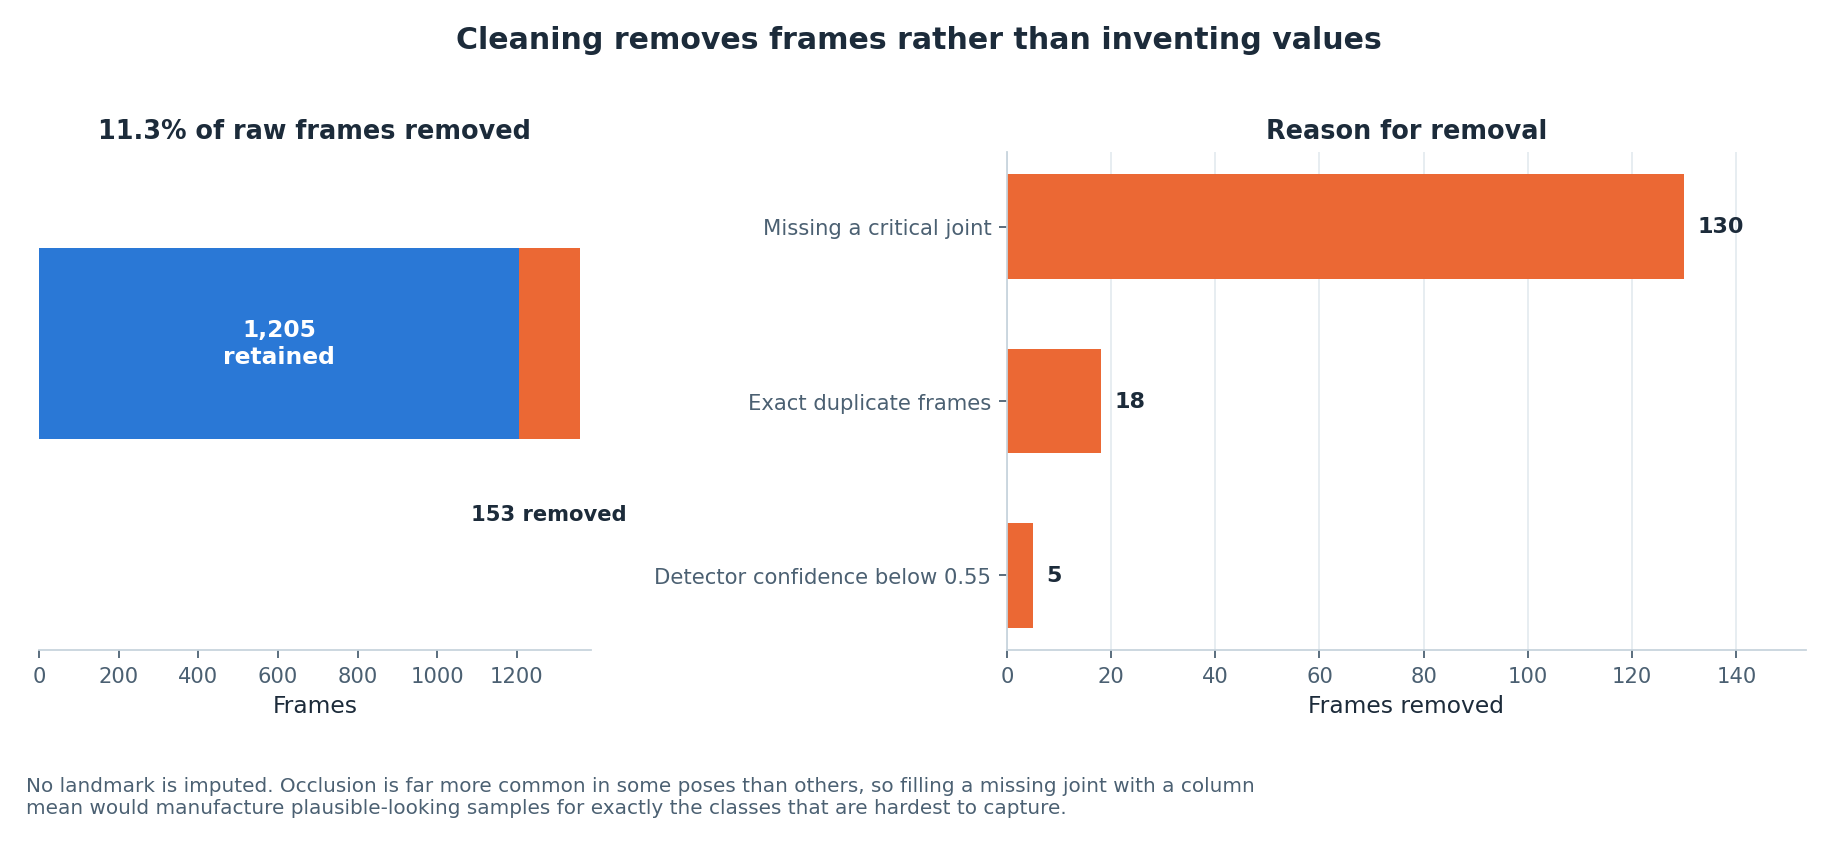

In [5]:
viz.fig_cleaning_waterfall(reasons, len(raw), len(clean))

## 3. Feature engineering

Three families of feature, and the reason for each:

1. **Normalised coordinates** — every joint translated to a hip-centred origin and
   divided by torso length. Without this the model learns where the child stood in
   the frame and how tall they are, not what they were doing.
2. **Joint angles** — the angle at a joint formed by its two neighbouring
   segments. Angles are invariant to translation, scale *and* body proportions,
   which is what an exercise classifier should key on.
3. **Inter-joint distances**, normalised by torso length — wrist-to-ankle
   separates Child's Pose from Thread the Needle; knee-to-hip separates lying
   from kneeling positions.

Frame-level features only. A real deployment would add velocity and movement
phase across a sliding window; the dataset here is independent frames.

In [6]:
features = build_feature_table(clean)
feature_names = [c for c in features.columns if c not in ("exercise", "subject_id")]

print(f"{len(features):,} samples x {len(feature_names)} features\n")
for family, cols in feature_families(feature_names).items():
    print(f"  {family:26s} {len(cols):>3d}")
features[feature_names[:6] + ["exercise"]].head()

772 samples x 45 features

  Normalised coordinates      26
  Joint angles                 9
  Inter-joint distances        9
  Detector quality             1


,n_head_x,n_head_y,n_neck_x,n_neck_y,n_sho_l_x,n_sho_l_y,exercise
0,-0.894159,0.655038,-0.793460,0.608622,-0.532758,0.576952,core_hip_stability
1,-0.036971,-1.315120,0.081429,-0.996679,-0.007749,-0.825304,calf_control
2,-0.834558,0.856835,-0.833172,0.553014,-0.599815,0.732617,cat_cow
3,-1.040317,0.463627,-0.875315,0.483554,-0.705689,0.253069,lower_limb
4,-1.257748,-0.281384,-0.999991,0.004333,-0.790105,-0.028602,cat_cow


## 4. Splitting the data

The split is by **subject**, not by frame. Frames from the same take are highly
correlated; a random frame-level split would put near-duplicate frames on both
sides and inflate the test score. This is the single most consequential decision
in the whole pipeline — and the easiest to get silently wrong.

The scaler is fitted on the **training partition only**. Fitting before splitting
leaks test statistics into training and produces a model that scores well and
generalises badly, with nothing in the output to indicate anything went wrong.

In [7]:
ds = prepare()
print(ds.summary())
print()
print("train class counts:", dict(pd.Series(ds.y_train).value_counts()))
print("test  class counts:", dict(pd.Series(ds.y_test).value_counts()))

train (577, 45)  test (195, 45)  45 features  6 classes  153 rows dropped in cleaning

train class counts: {'lower_limb': np.int64(144), 'cat_cow': np.int64(104), 'core_hip_stability': np.int64(99), 'childs_pose': np.int64(86), 'calf_control': np.int64(78), 'thread_the_needle': np.int64(66)}
test  class counts: {'core_hip_stability': np.int64(55), 'lower_limb': np.int64(40), 'cat_cow': np.int64(36), 'childs_pose': np.int64(28), 'thread_the_needle': np.int64(22), 'calf_control': np.int64(14)}


Note the test-set class distribution is not proportional to the training set.
That is a direct consequence of splitting by subject: whole takes move to one
side or the other, so the classes recorded in fewer takes are unevenly
represented. It is a real property of subject-level splits and is reported here
rather than smoothed over.

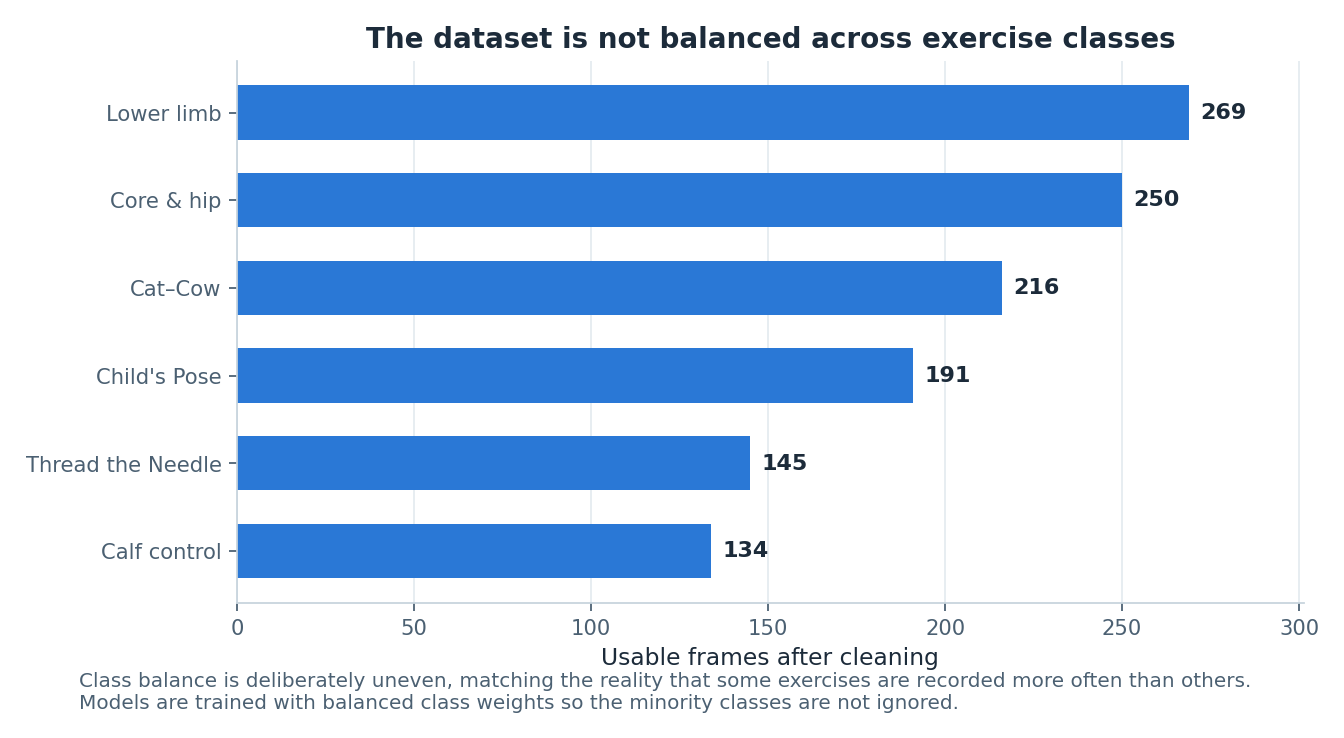

In [8]:
viz.fig_class_balance(clean)

## 5. Exploratory analysis

### 5.1 Skeleton visualisation

Each pose row is rendered using the same connection list as the stick figures in
the web platform, so the notebook and the interface draw the same skeleton.

The representative frame for each class is the one **closest to the class mean**,
not simply the first. An unrepresentative frame produces a figure that is
visually convincing and factually wrong — a reminder that in this project the
data-preparation choices are also communication choices.

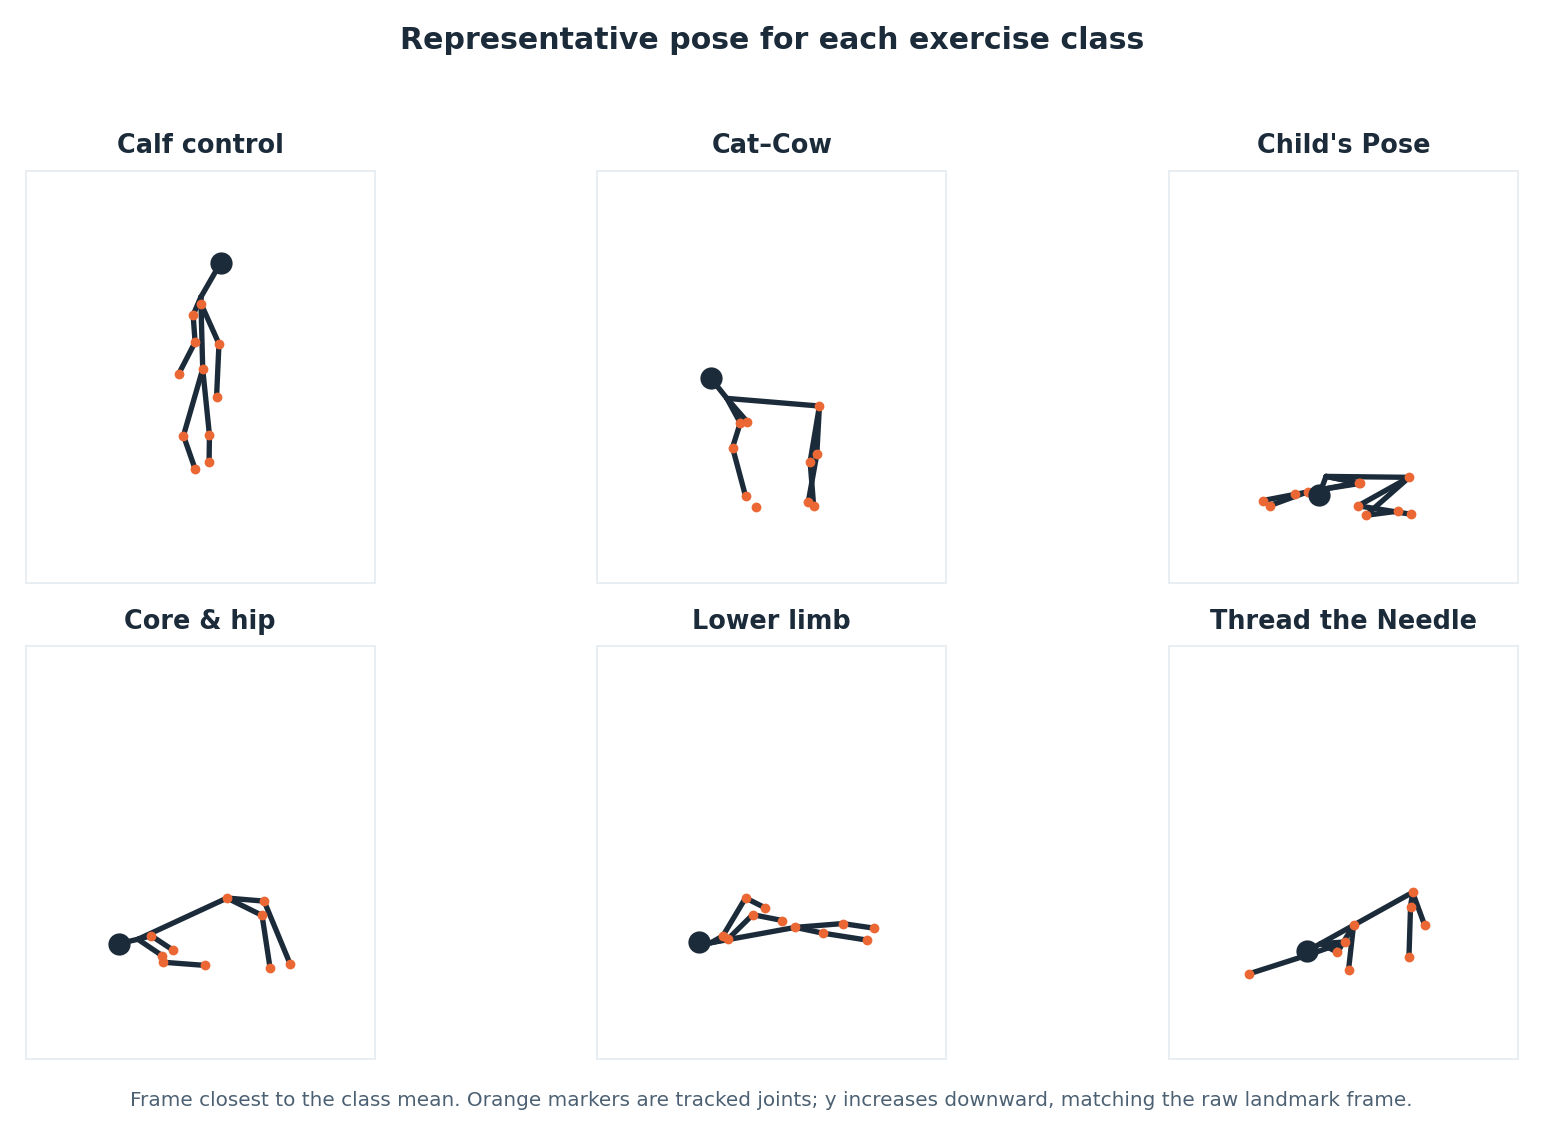

In [9]:
viz.fig_pose_gallery(clean)

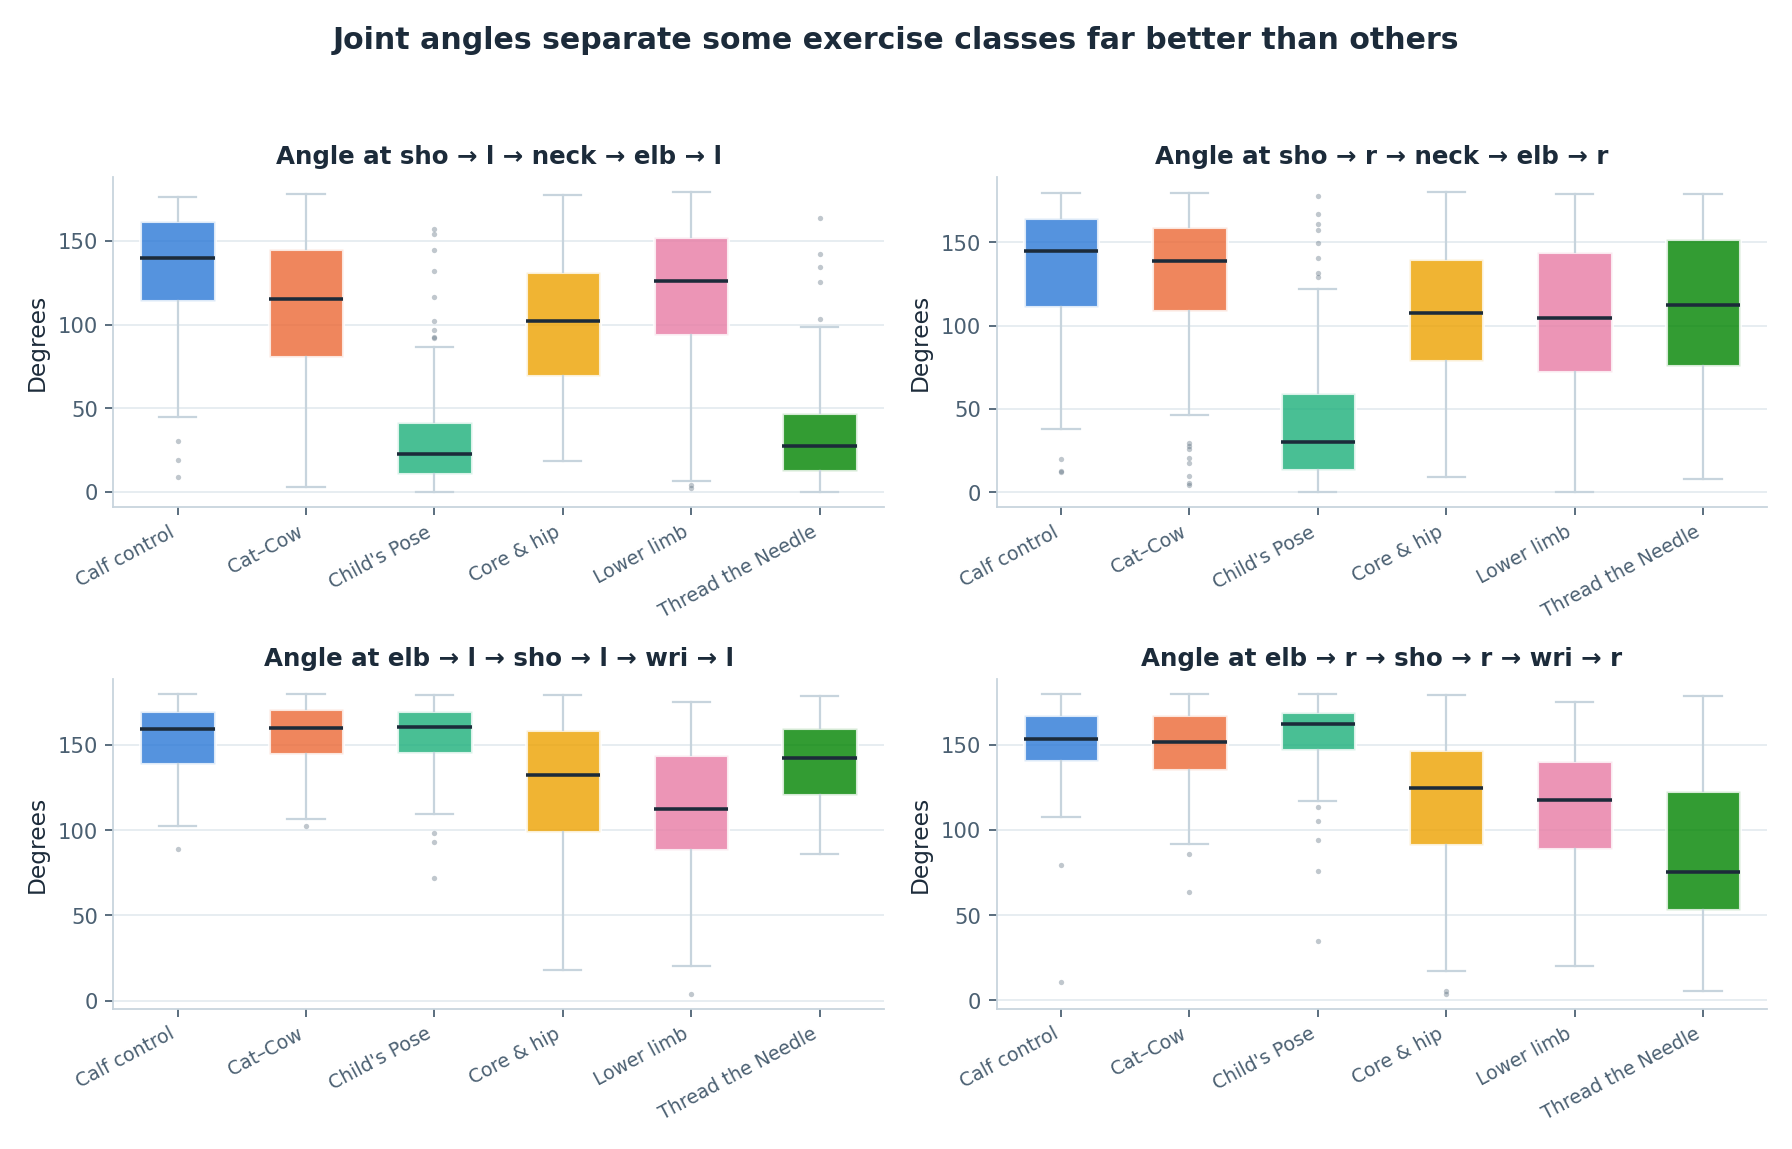

In [10]:
viz.fig_angle_distributions(features)

### 5.2 PCA

A projection onto the first two principal components gives a visual indication of
how separable the classes are before any classifier is trained.

The two components account for only part of the total variance, so the plot is
**an indication of separability, not proof of it**. The explained variance is
printed alongside so the reader can judge for themselves.

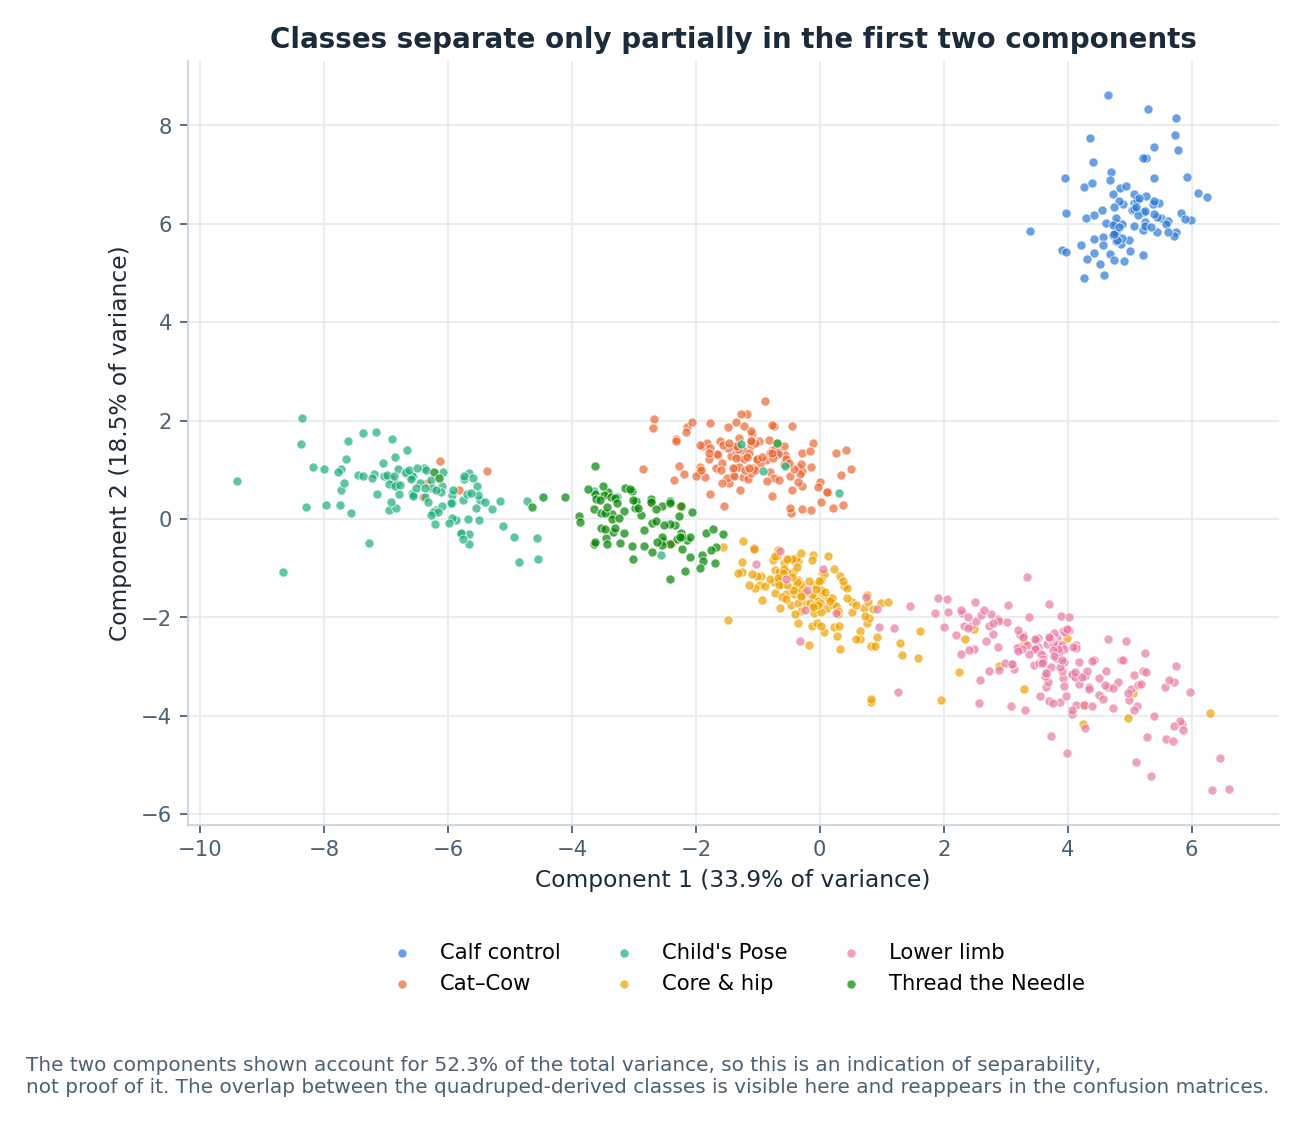

In [11]:
viz.fig_pca(features, feature_names)

## 6. Modelling

Three model families are compared on identical data and identical splits:

* **Random Forest** — bagged trees, the project baseline.
* **Gradient Boosting** — boosted trees, a stronger tree-based comparison.
* **Neural network (MLP)** — a different model family entirely, so the comparison
  is not confined to trees.

Random Forest `max_depth` is constrained deliberately. Left unrestricted it fits
the training data almost perfectly and generalises noticeably worse, with nothing
in the output to signal that anything went wrong.

Model selection uses cross-validation on the training set. **The test set is
scored exactly once, at the end.**

In [12]:
for name, model in build_models().items():
    print(f"{name}:")
    for k, v in model.get_params().items():
        if k in ("n_estimators", "max_depth", "learning_rate", "hidden_layer_sizes",
                 "alpha", "max_iter", "min_samples_leaf", "class_weight", "activation"):
            print(f"    {k:20s} {v}")

Random Forest:
    class_weight         balanced
    max_depth            12
    min_samples_leaf     2
    n_estimators         300
Gradient Boosting:
    learning_rate        0.1
    max_depth            3
    min_samples_leaf     1
    n_estimators         150
Neural Network:
    activation           relu
    alpha                0.001
    hidden_layer_sizes   (128, 64)
    learning_rate        constant
    max_iter             1500


In [13]:
results = run_comparison(ds)
for r in results.values():
    print(r)

Random Forest        acc=0.928  macroF1=0.935  cv=0.955±0.017  gap=+0.037
Gradient Boosting    acc=0.923  macroF1=0.931  cv=0.939±0.016  gap=+0.077
Neural Network       acc=0.923  macroF1=0.932  cv=0.939±0.019  gap=+0.077


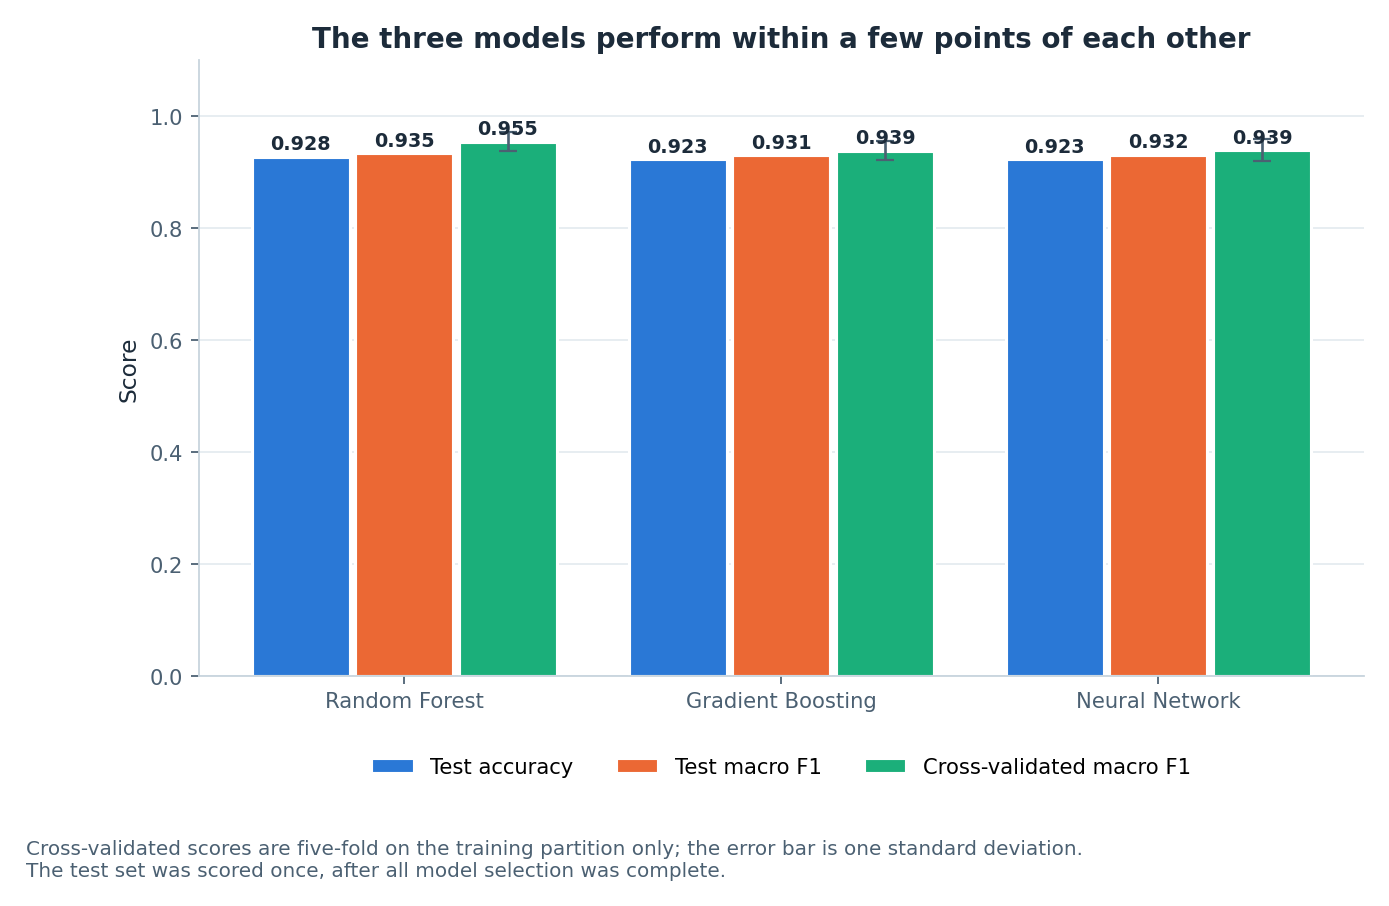

In [14]:
viz.fig_model_comparison(results)

### 6.1 Overfitting

The gap between training and test accuracy is the honest signal. A model that
scores 1.000 on its training data has memorised it; whether that matters is
answered by how far the test score falls behind.

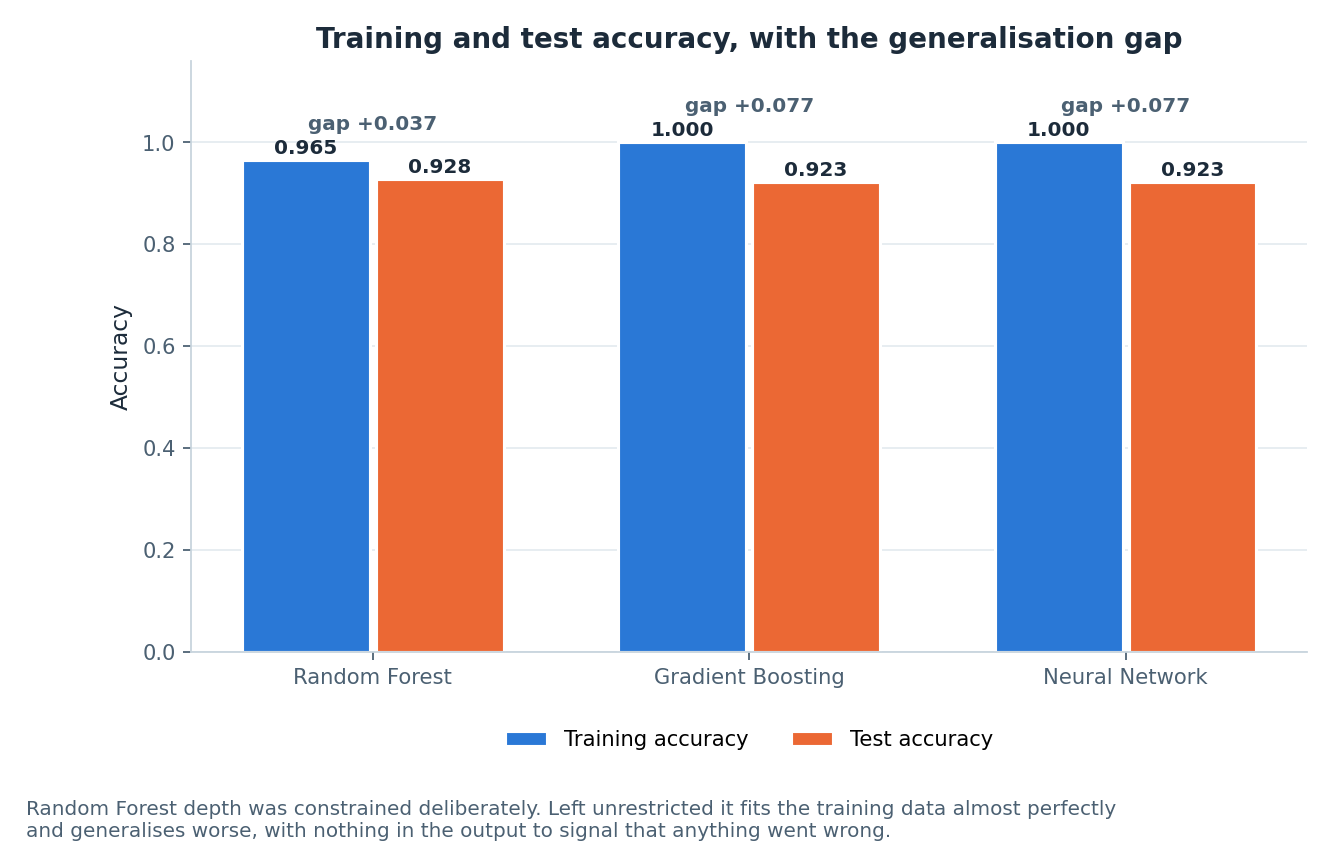

In [15]:
viz.fig_overfit_gap(results)

## 7. Evaluation

Accuracy alone is not enough here. For a system that gives feedback to a parent
about a child's movement, an exercise class the model quietly gets wrong is a
more serious failure than a slightly lower overall score. So the evaluation is
reported **per class**.

In [16]:
best_name = max(results, key=lambda n: results[n].macro_f1)
best = results[best_name]
print(f"best model by macro F1: {best_name}\n")
print(report_text(best, ds.y_test))

best model by macro F1: Random Forest

                    precision    recall  f1-score   support

      calf_control       1.00      1.00      1.00        14
           cat_cow       0.97      0.92      0.94        36
       childs_pose       0.88      1.00      0.93        28
core_hip_stability       0.93      0.93      0.93        55
        lower_limb       0.90      0.90      0.90        40
 thread_the_needle       0.95      0.86      0.90        22

          accuracy                           0.93       195
         macro avg       0.94      0.93      0.93       195
      weighted avg       0.93      0.93      0.93       195



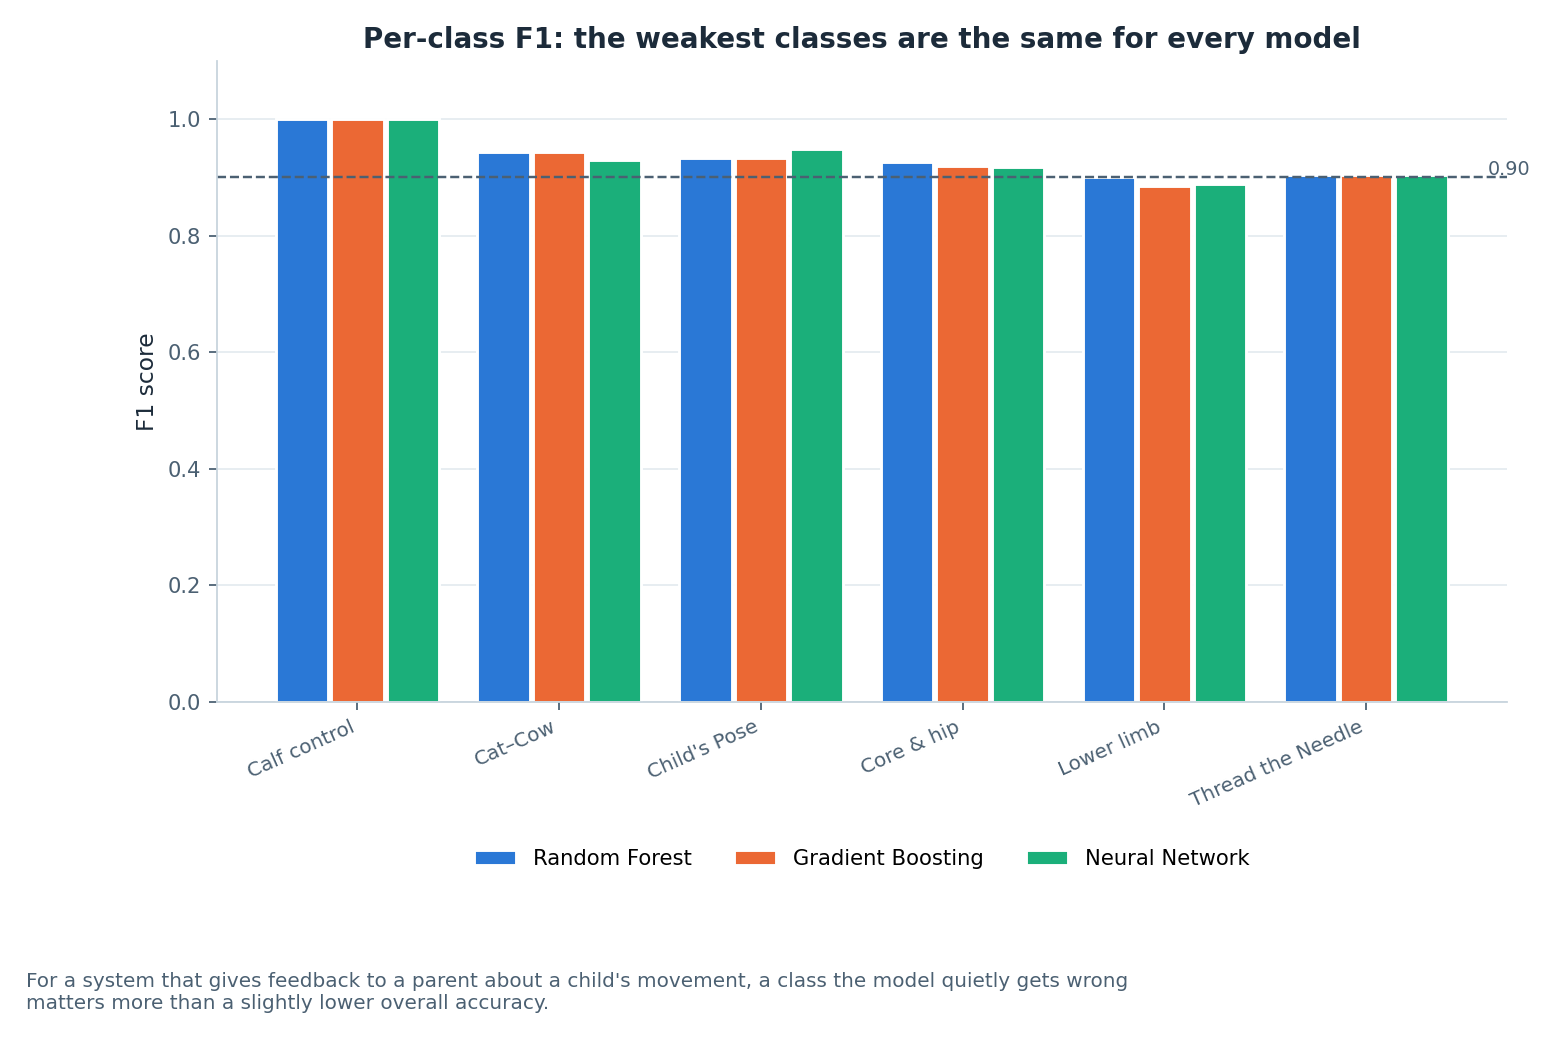

In [17]:
viz.fig_per_class_f1(results)

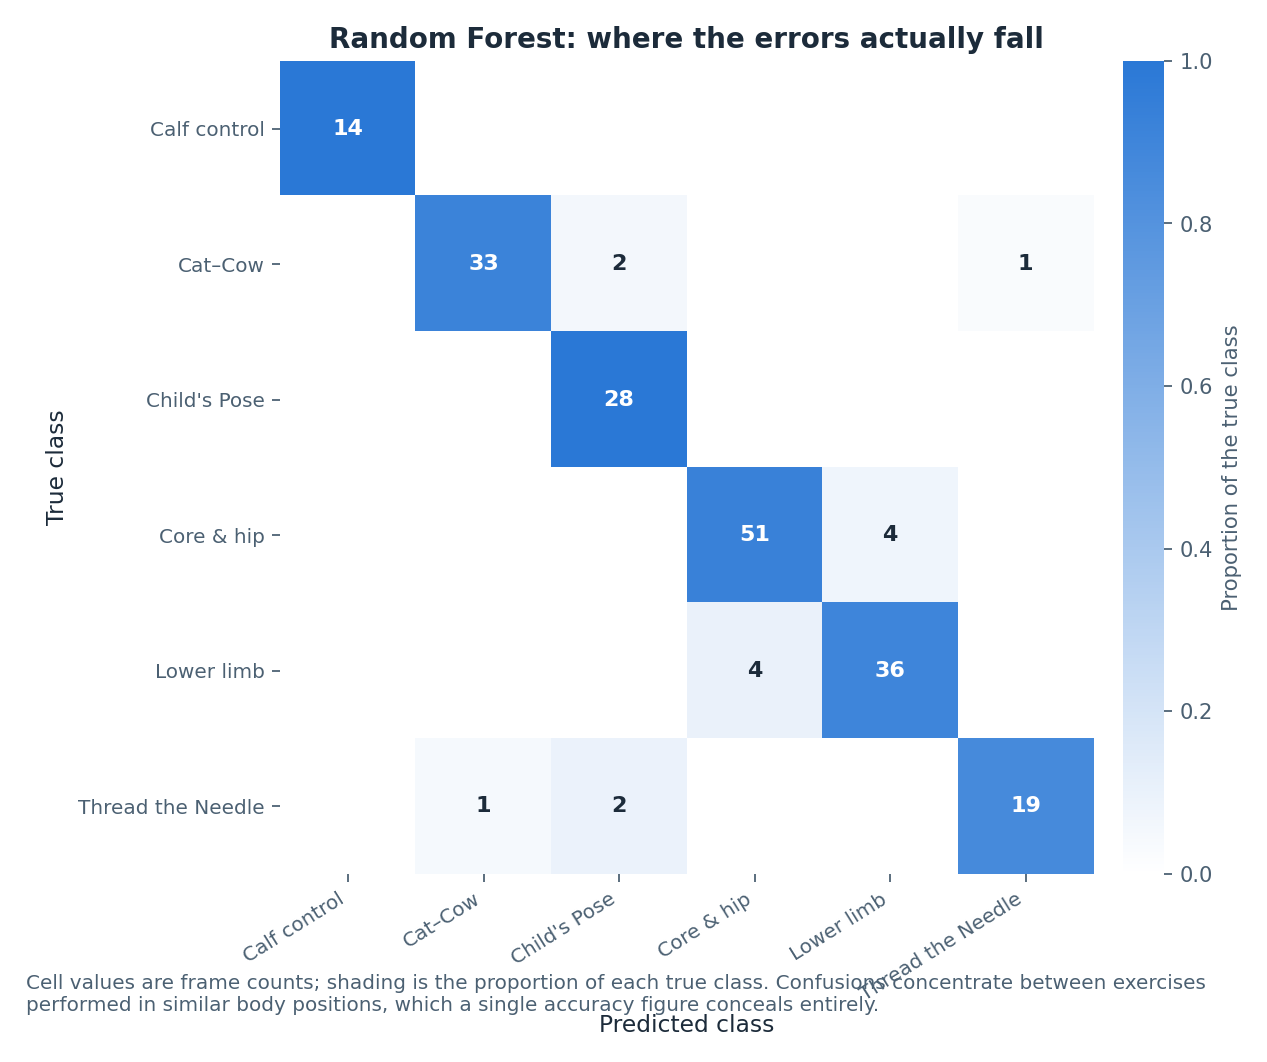

In [18]:
viz.fig_confusion(best)

In [19]:
print("Weakest classes for each model:\n")
for name, r in results.items():
    worst = weakest_classes(r, n=2)
    print(f"  {name:20s} " + ", ".join(f"{viz.label(c)} (F1 {f:.2f})" for c, f in worst))

Weakest classes for each model:

  Random Forest        Lower limb (F1 0.90), Thread the Needle (F1 0.90)
  Gradient Boosting    Lower limb (F1 0.89), Thread the Needle (F1 0.90)
  Neural Network       Lower limb (F1 0.89), Thread the Needle (F1 0.90)


The confusions are not random. They concentrate between exercises performed in
similar body positions — the quadruped-derived classes with each other, and the
two classes performed lying down with each other. That is exactly the structure
that was deliberately built into the generator, and exactly what appeared in the
PCA projection. Frame-level features cannot separate poses that genuinely look
alike at some phase of the movement; distinguishing them needs temporal context.

In [20]:
from src.models import feature_importance
rf = build_models()["Random Forest"]
rf.fit(ds.X_train, ds.y_train)

for name, imp in feature_importance(rf, ds.feature_names, top=8):
    print(f"  {imp:.4f}  {name}")

  0.0755  n_wri_l_x
  0.0685  dist_wri_l_wri_r
  0.0657  n_head_y
  0.0530  n_neck_y
  0.0472  n_elb_l_x
  0.0438  n_sho_r_y
  0.0438  n_wri_r_x
  0.0430  n_elb_r_x


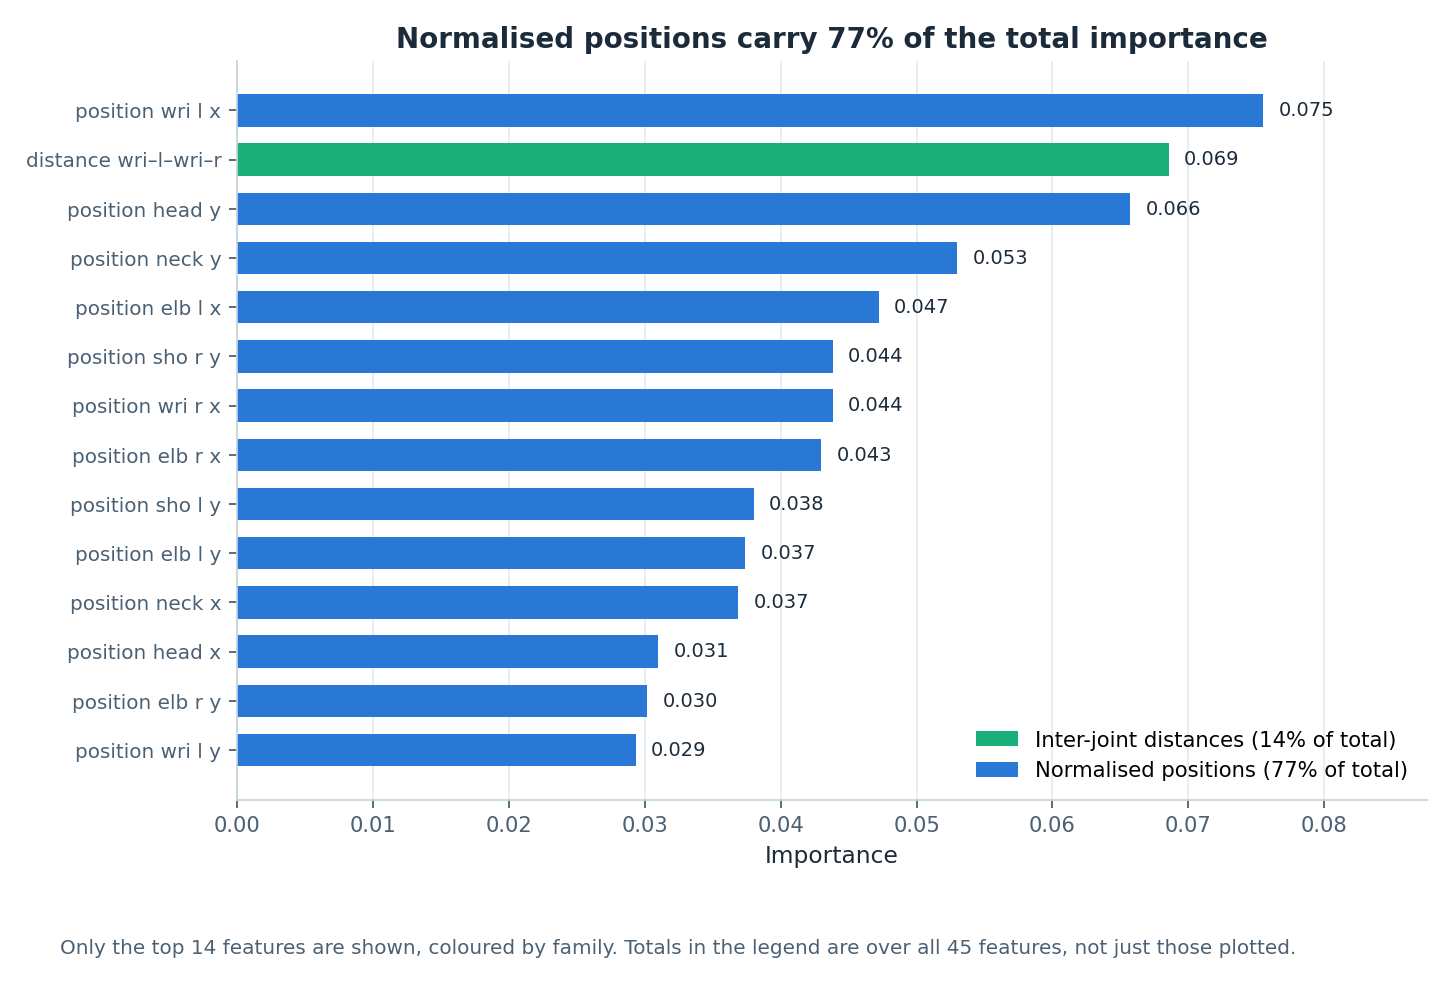

In [21]:
viz.fig_feature_importance(rf, ds.feature_names)

## 8. From results to a usable platform

The classifier above is one component. The platform a parent actually opens does
three things, and this section covers the two that are not machine learning.

### 8.1 Turning a description into steps

The step splitter takes a written exercise description and separates it into
ordered, actionable steps, extracting hold times, repetition counts and safety
notes.

**It is a rule-based linguistic engine, not a language model.** No model weights
are loaded and no network call is made. The pipeline is: normalise → detect an
existing numbered or bulleted structure → sentence-segment → split on connectives
only where both halves read as instructions → classify each fragment → extract
parameters → score.

In [22]:
from src.splitter import split_exercise

demo = ("Lay on your back with your leg straight. Point your foot and toes down "
        "to the floor or bed, then slowly pull your foot and toes up towards "
        "your knee. Repeat 10 times. Stop if pain becomes worse and seek advice "
        "from a healthcare professional.")

res = split_exercise(demo)
print(f"method: {res.method}    overall confidence: {res.confidence}\n")
for s in res.steps:
    extra = []
    if s.reps: extra.append(f"{s.reps}x")
    if s.hold_s: extra.append(f"{s.hold_s}s hold")
    print(f"  {s.n}. [{s.kind:8s}] {s.text}" + (f"   ({', '.join(extra)})" if extra else ""))
for w in res.safety:
    print(f"\n  SAFETY (kept out of the steps): {w}")

method: rule-based    overall confidence: 0.86

  1. [action  ] Lay on your back with your leg straight.
  2. [action  ] Point your foot and toes down to the floor or bed.
  3. [action  ] Slowly pull your foot and toes up towards your knee.
  4. [reps    ] Repeat 10 times.   (10x)

  SAFETY (kept out of the steps): Stop if pain becomes worse and seek advice from a healthcare professional.


In [23]:
# An already-numbered description must not be re-split.
numbered = ("1. Kneel on the floor with your knees apart.\n"
            "2. Sit back onto your heels.\n"
            "3. Fold forward and rest your tummy between your thighs.\n"
            "4. Hold for 20 seconds and breathe slowly.")

r2 = split_exercise(numbered)
print(f"method: {r2.method}   steps: {len(r2.steps)}")
for s in r2.steps:
    print(f"  {s.n}. {s.text}" + (f"   ({s.hold_s}s hold)" if s.hold_s else ""))

method: explicit-numbered   steps: 4
  1. Kneel on the floor with your knees apart.
  2. Sit back onto your heels.
  3. Fold forward and rest your tummy between your thighs.
  4. Hold for 20 seconds and breathe slowly.   (20s hold)


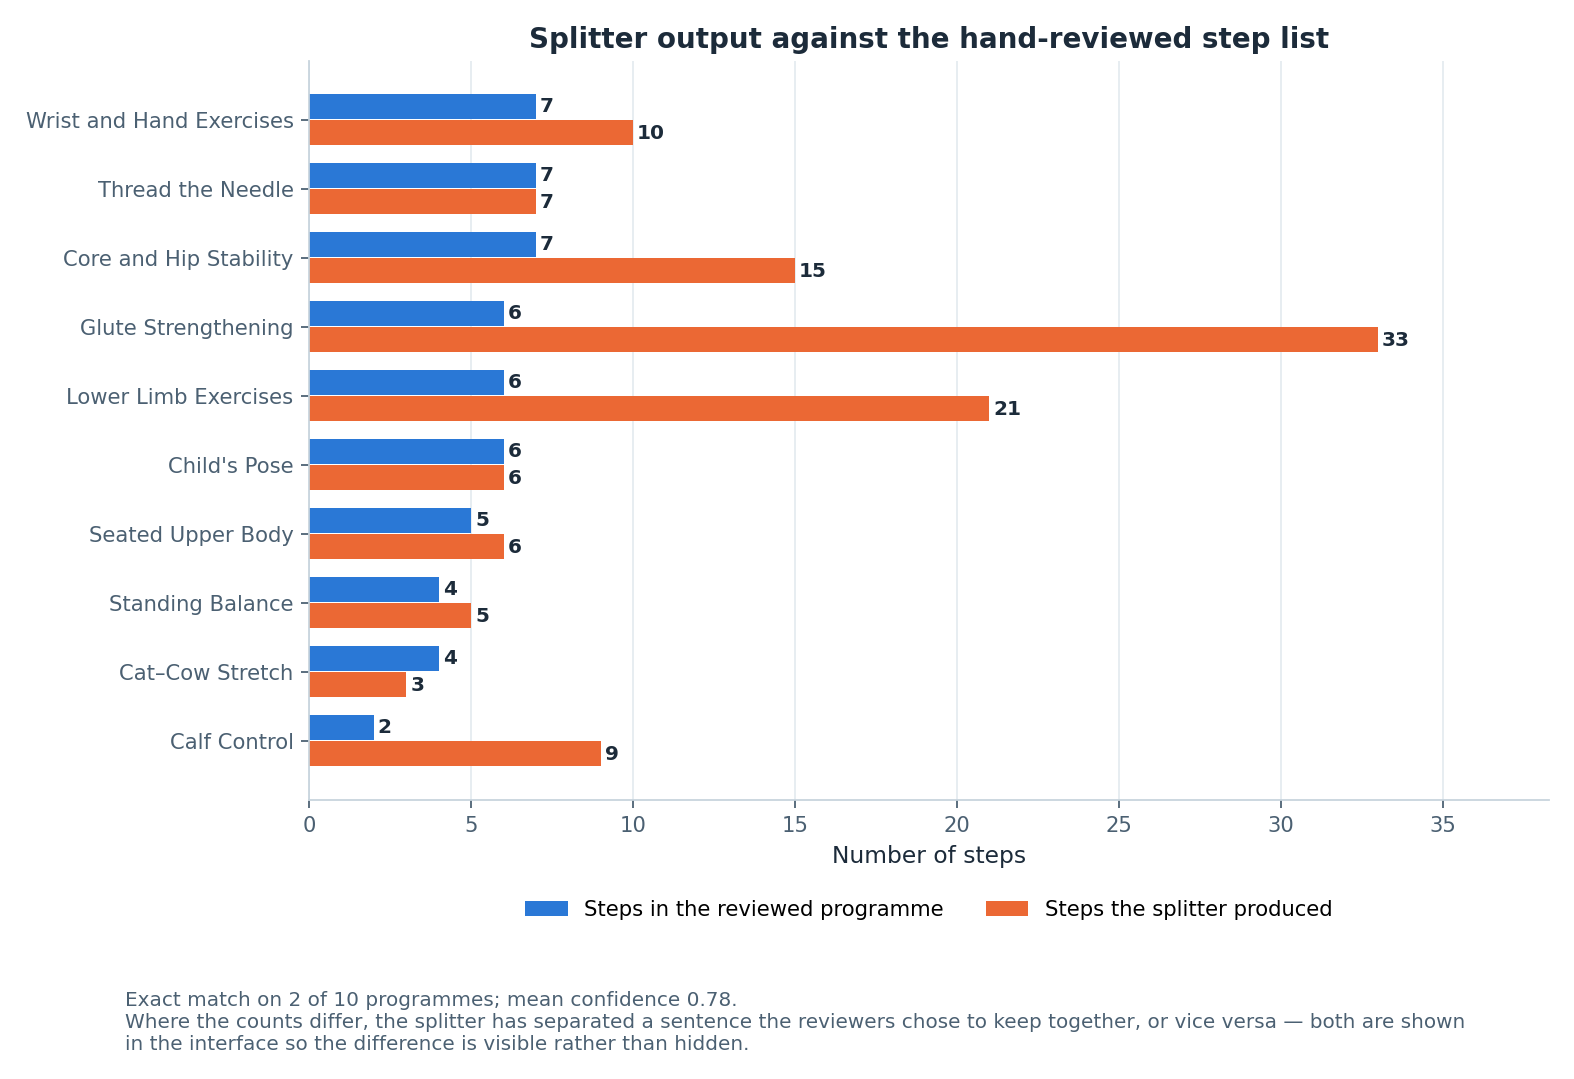

In [24]:
viz.fig_splitter_performance()

Where the splitter's step count differs from the reviewed programme, it has
usually separated a sentence the reviewers chose to group, or grouped one they
chose to separate — most visibly on the multi-exercise NHS leaflets, where one
"step" in the reviewed programme covers a whole sub-exercise. The interface shows
the original description beside the generated steps precisely so this difference
is visible to the reader rather than hidden.

### 8.2 The pose coach

The live coach compares four joint angles measured from the camera against target
angles **derived from the same hand-authored pose bank the illustrations are
drawn from**. The child is therefore checked against exactly the position the
picture shows.

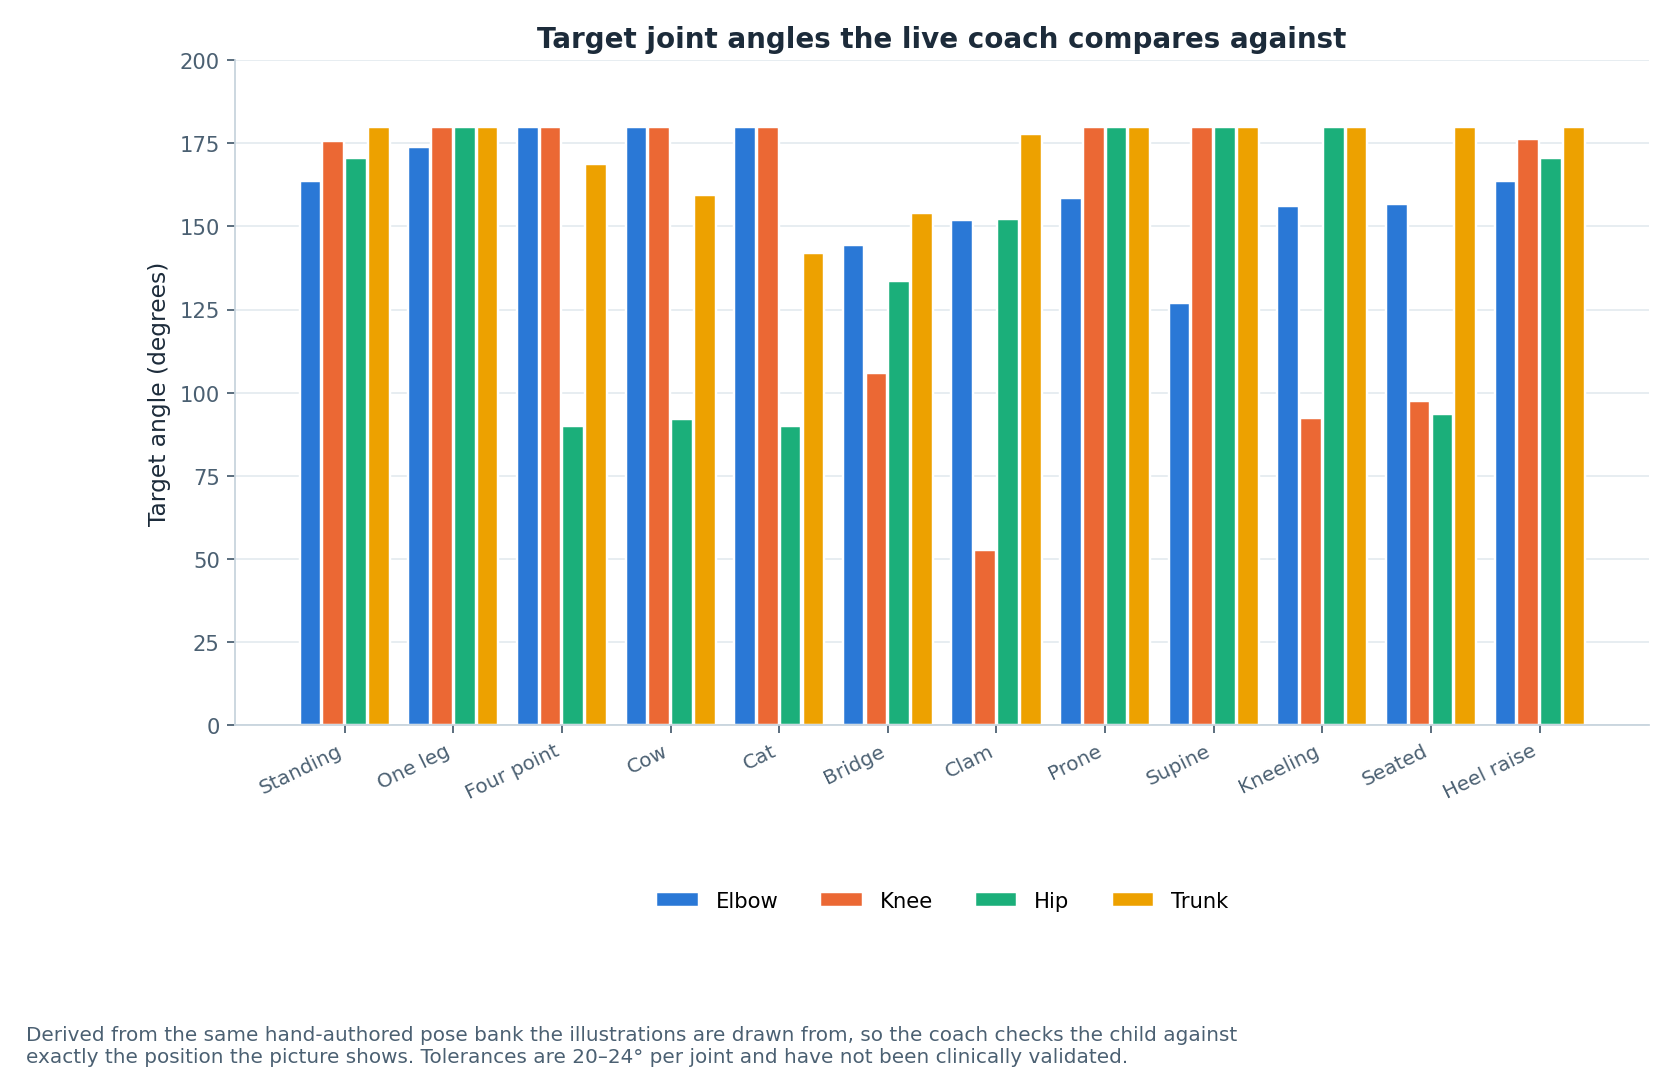

In [25]:
viz.fig_coach_targets()

## 9. Limitations

Stated plainly, because a result that is not qualified is not a result.

1. **The dataset is synthetic.** Every accuracy figure describes the generator,
   not children. This is the single largest limitation and it bounds every claim
   in this notebook.
2. **No temporal modelling.** Features are frame-level. The confusions that remain
   are precisely those a movement-over-time model would be expected to resolve.
3. **No clinical validation.** No physiotherapist has reviewed the step splitting,
   the illustrations or the coach's angle tolerances, and no child has used the
   platform.
4. **The splitter is rule-based.** It handles leaflet prose well and would handle
   messier, conversational descriptions worse. A language model is the obvious
   next step; it is not implemented, and doing it properly needs a server-side
   key, schema validation, and a clinical safety review, because a model can
   invent an instruction that was not in the source text.
5. **The pose coach is uncalibrated.** The 20–24° tolerances are engineering
   judgement, not clinical thresholds.
6. **Illustrations are hand-authored**, not generated. They are a stand-in for a
   generative vision model.

## 10. Next steps

1. Obtain ethical approval and record a small, consented dataset — even 20
   participants would let every number here be re-derived from reality.
2. Add temporal features over a sliding window and re-run this comparison; the
   confusion structure predicts where the gain would appear.
3. Have a physiotherapist review the generated step lists and the coach
   tolerances.
4. Connect a language model to the splitter behind a validating proxy, keeping
   the rule-based engine as the fallback.
5. Evaluate with families: does the platform actually change whether the exercises
   get done, and done correctly?